# The Case for Private Markets, Told Entirely From Public Data

*StartEngine research notebook · June 2026 · draft for internal review*

Three facts about American capital markets, each drawn from a primary public source —
the SEC, the IRS, the Census Bureau, and the Federal Reserve's FRED database — and each pulled **live by
the code in [this notebook](https://github.com/StartEngine/private-markets-research/blob/main/private_markets.ipynb)**, so every figure is reproducible by anyone who runs it:

1. **The public stock market has been shrinking for nearly three decades.**
2. **Capital formation didn't shrink with it — it moved into private markets.**
3. **The millions of investors who qualify to participate have historically had almost no
   visibility into that market — deal flow lived inside closed networks.**

None of this is a forecast, and none of it is investment advice. It is simply what the
public record says — and together, it is the clearest picture of why private markets are
one of the largest under-served opportunities in American investing — and why access to
them is becoming a product.

In [1]:
import os, datetime as dt, asyncio, sqlite3, json, logging
from types import SimpleNamespace

# Cap noisy INFO loggers: httpx logs full request URLs (which carry API keys
# as query params) and matplotlib chatters about categorical axes.
for _name in ("httpx", "httpcore", "matplotlib"):
    logging.getLogger(_name).setLevel(logging.WARNING)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import Markdown, display

def callout(text):
    display(Markdown(f"> **{text}**"))
from IPython.display import Markdown, display

def callout(text):
    display(Markdown(f"> **{text}**"))

# --- the four open-source data servers (installed from PyPI) ---------------
os.environ.setdefault("EDGAR_MCP_USER_AGENT", "StartEngine research devender@startengine.com")
assert os.environ.get("FRED_API_KEY"), "set FRED_API_KEY (free: fred.stlouisfed.org/docs/api/api_key_request.html)"

from fred_mcp import server as fred_server
from fred_mcp.fred_client import FredClient
from edgar_mcp import server as edgar_server
from edgar_mcp.edgar_client import EdgarClient
from mcpwright_core import cache_path

def _ctx(**resources):
    """Minimal MCP Context stand-in so we can call the servers' tools directly."""
    return SimpleNamespace(request_context=SimpleNamespace(lifespan_context=SimpleNamespace(**resources)))

fred_client = FredClient()
edgar_client = EdgarClient()
FRED = _ctx(fred=fred_client)
EDGAR = _ctx(edgar=edgar_client)
SOI_DB = cache_path("mcpwright-soi", "soi.sqlite3", "SOI_MCP_STORE")
ACS_DB = cache_path("mcpwright-census", "acs.sqlite3", "CENSUS_MCP_STORE")

# StartEngine brand palette
ACCENT, DEEP, DIM, GOOD = "#01D1B8", "#185C65", "#9AA5A6", "#185C65"
sns.set_theme(style="whitegrid", context="notebook", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
TODAY = dt.date.today()
display(Markdown(f"*All live figures in this document were pulled on {TODAY.isoformat()}.*"))

*All live figures in this document were pulled on 2026-06-10.*

## 1 · The public stock market has been shrinking for nearly three decades

In 1996 the United States had more listed companies, per person, than at any point before
or since. Then the IPO stopped being the default destination for a growing company.
Companies now stay private longer — often through their fastest-growing years — and many
never list at all. The World Bank tracks listed companies per capita; the Federal Reserve's
FRED database carries the series.

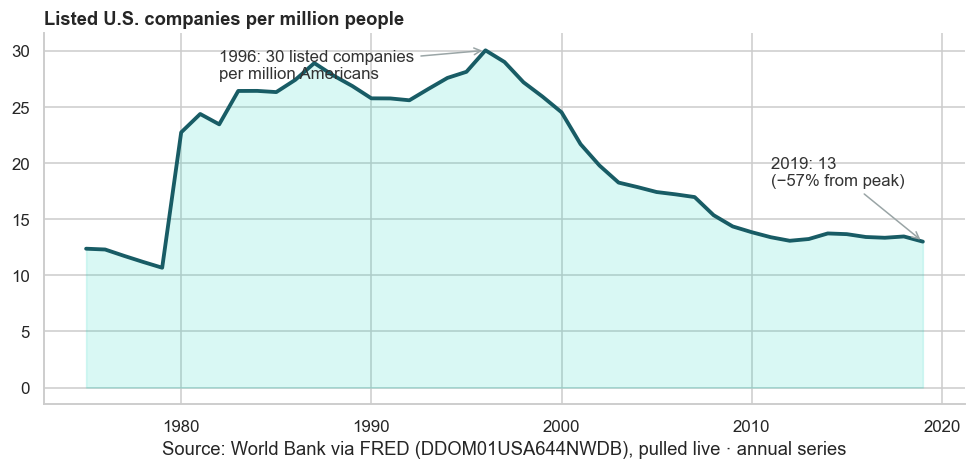

> **Peak 1996: 30 listed companies per million Americans → 2019: 13 — a 57% decline.**

In [2]:
hits = await fred_server.search_series("listed companies United States", FRED, limit=1)
series_id = hits[0].series_id
listed = await fred_server.get_observations(series_id, FRED, max_points=60)
pts = [(int(o.date[:4]), o.value) for o in listed.observations if o.value is not None]
years, vals = zip(*pts)
peak_year, peak = max(pts, key=lambda p: p[1])
last_year, last = pts[-1]
decline = (peak - last) / peak * 100

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(years, vals, color=DEEP, lw=2.5)
ax.fill_between(years, vals, color=ACCENT, alpha=0.15)
ax.annotate(f"{peak_year}: {peak:.0f} listed companies\nper million Americans",
            xy=(peak_year, peak), xytext=(peak_year - 14, peak - 2.5),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
ax.annotate(f"{last_year}: {last:.0f}\n(−{decline:.0f}% from peak)",
            xy=(last_year, last), xytext=(last_year - 8, last + 5),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
ax.set_title("Listed U.S. companies per million people", loc="left", fontweight="bold")
ax.set_xlabel(f"Source: World Bank via FRED ({series_id}), pulled live · annual series")
plt.tight_layout(); plt.show()

callout(f"Peak {peak_year}: {peak:.0f} listed companies per million Americans → {last_year}: "
        f"{last:.0f} — a {decline:.0f}% decline.")

The U.S. population grew by a quarter over this period; the number of public companies
fell anyway. (The World Bank series ends in 2019, so the chart shows the first 23 years
of the slide.) The consequence for investors is structural: **by the time a company reaches
the public market — if it ever does — much of its growth has already happened**, captured
by whoever was allowed to own it while it was private.

## 2 · Capital formation didn't shrink. It moved.

If companies aren't going public, where is the capital being raised? The SEC's own filing
system answers in real time: every private placement under Regulation D files a **Form D**.
The cell below counts every month of Form D filings since 2010 — the first full year of
mandatory electronic filing — live from SEC EDGAR's search index.

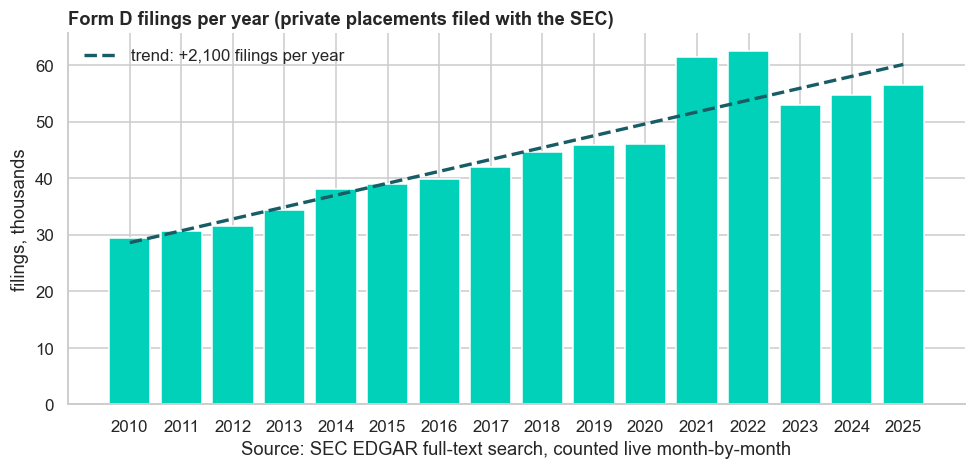

> **From 29,447 Form D filings in 2010 to 56,517 in 2025 — up 92% overall, off the 2021–22 peak — with 59,898 in the last 12 months alone (about 164 new filings every day).**

In [3]:
import numpy as np

async def month_total(form, y, m):
    start = dt.date(y, m, 1)
    end = (dt.date(y + (m == 12), m % 12 + 1, 1) - dt.timedelta(days=1))
    data = await edgar_client.full_text_search(forms=[form], date_from=start.isoformat(),
                                               date_to=end.isoformat())
    return data.get("hits", {}).get("total", {}).get("value", 0)

# Every month since 2010 (the index caps any single count at 10,000, so annual
# totals must be assembled from monthly counts).
all_months = []
y, m = 2010, 1
while (y, m) < (TODAY.year, TODAY.month):
    all_months.append((y, m))
    m += 1
    if m == 13:
        y, m = y + 1, 1

formd_monthly = [await month_total("D", y, m) for y, m in all_months]
months = all_months[-12:]          # the trailing window, reused below
total_12mo = sum(formd_monthly[-12:])

annual: dict[int, int] = {}
for (yy, mm), v in zip(all_months, formd_monthly):
    annual[yy] = annual.get(yy, 0) + v
full_years = [yy for yy in sorted(annual) if yy < TODAY.year]
vals = [annual[yy] for yy in full_years]
slope, intercept = np.polyfit(full_years, vals, 1)
growth = (vals[-1] / vals[0] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar([str(yy) for yy in full_years], [v / 1000 for v in vals], color=ACCENT)
ax.plot(range(len(full_years)), [(slope * yy + intercept) / 1000 for yy in full_years],
        color=DEEP, lw=2.2, ls="--", label=f"trend: +{slope:,.0f} filings per year")
ax.set_title("Form D filings per year (private placements filed with the SEC)",
             loc="left", fontweight="bold")
ax.set_ylabel("filings, thousands")
ax.set_xlabel("Source: SEC EDGAR full-text search, counted live month-by-month")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

callout(f"From {vals[0]:,} Form D filings in 2010 to {vals[-1]:,} in {full_years[-1]} — up "
        f"{growth:.0f}% overall, off the 2021–22 peak — with {total_12mo:,} in the last 12 "
        f"months alone (about {total_12mo//365} new filings every day).")

How does that compare with the public on-ramp? Counting from the same SEC index over the
same twelve months: **Form D** filings (private placements — by operating companies *and*
pooled funds) versus **S-1** registration statements (the doorway to the registered public
market) versus **424B4** final prospectuses (*priced* public offerings — IPOs and
follow-ons alike). And in dollars, the SEC's latest
[capital formation data](https://www.sec.gov/data-research/statistics-data-visualizations/regulation-d-offerings)
(July 2023–June 2024) puts exempt offerings by operating companies at about
**\$949 billion** against about **\$28 billion** of IPOs — including pooled funds,
Regulation D alone has run at **\$2.5+ trillion a year**.

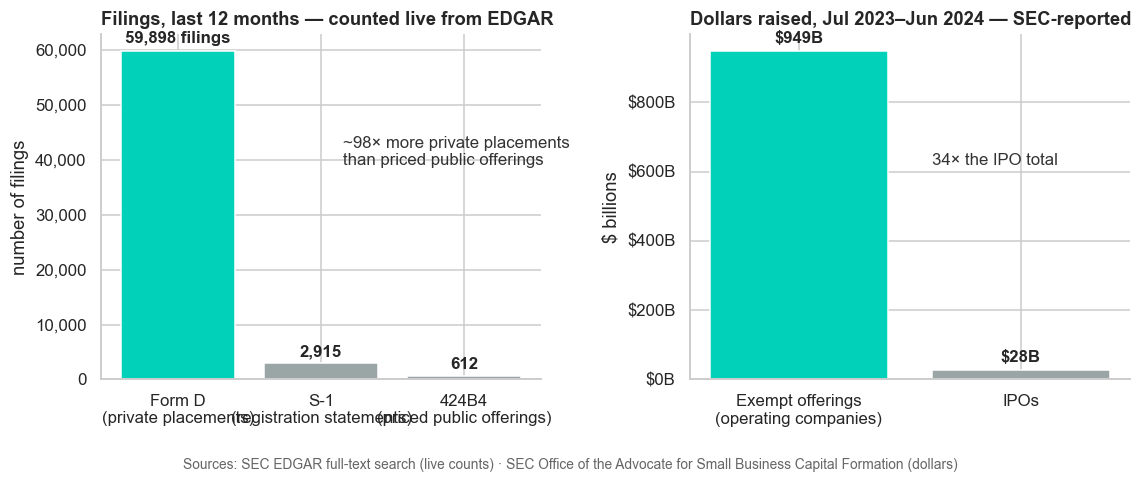

> **Last 12 months: 59,898 private-placement filings vs 2,915 registration statements vs 612 priced public offerings — roughly 98× more exempt filings than priced public deals. (Form D spans operating companies and pooled funds; 424B4 includes follow-ons.)**

In [4]:
s1_total = sum([await month_total("S-1", y, m) for y, m in months])
b4_total = sum([await month_total("424B4", y, m) for y, m in months])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))

counts = [total_12mo, s1_total, b4_total]
count_labels = ["Form D\n(private placements)", "S-1\n(registration statements)", "424B4\n(priced public offerings)"]
bars = ax1.bar(count_labels, counts, color=[ACCENT, DIM, DIM])
ax1.bar_label(bars, labels=[f"{counts[0]:,} filings", f"{counts[1]:,}", f"{counts[2]:,}"],
              padding=3, fontweight="bold")
ax1.set_title("Filings, last 12 months — counted live from EDGAR", loc="left", fontweight="bold")
ax1.set_ylabel("number of filings")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax1.annotate(f"~{total_12mo / b4_total:.0f}× more private placements\nthan priced public offerings",
             xy=(0.55, 0.62), xycoords="axes fraction", color="#333")

dollars = [949, 28]
dollar_labels = ["Exempt offerings\n(operating companies)", "IPOs"]
bars2 = ax2.bar(dollar_labels, dollars, color=[ACCENT, DIM])
ax2.bar_label(bars2, fmt="$%gB", padding=3, fontweight="bold")
ax2.set_title("Dollars raised, Jul 2023–Jun 2024 — SEC-reported", loc="left", fontweight="bold")
ax2.set_ylabel("$ billions")
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}B"))
ax2.annotate("34× the IPO total", xy=(0.55, 0.62), xycoords="axes fraction", color="#333")

fig.supxlabel("Sources: SEC EDGAR full-text search (live counts) · SEC Office of the Advocate for "
              "Small Business Capital Formation (dollars)", fontsize=9, color="#666")
plt.tight_layout(); plt.show()

callout(f"Last 12 months: {total_12mo:,} private-placement filings vs {s1_total:,} registration "
        f"statements vs {b4_total:,} priced public offerings — roughly "
        f"{total_12mo/b4_total:.0f}× more exempt filings than priced public deals. "
        f"(Form D spans operating companies and pooled funds; 424B4 includes follow-ons.)")

The American capital market did not get smaller. It went private.

## 3 · A large audience that couldn't see the market

Participating in that market generally requires being an
**accredited investor** — income above \$200,000 individually (or \$300,000 with a
spouse) in each of the last two years, or \$1 million in net worth excluding the primary
residence. How large is that audience? The IRS
publishes the answer, aggregated from every filed tax return — and it is far larger than
the room the deals have been getting done in.

<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
/var/folders/v4/2_ch3kcd0z5b0td0hzd0trgc0000gn/T/ipykernel_31102/1764427806.py:17: SyntaxWarning: invalid escape sequence '\$'
  ax.annotate(f"{over/1e6:.1f}M returns above \$200k AGI — an upper\nbound on the income-qualified audience",


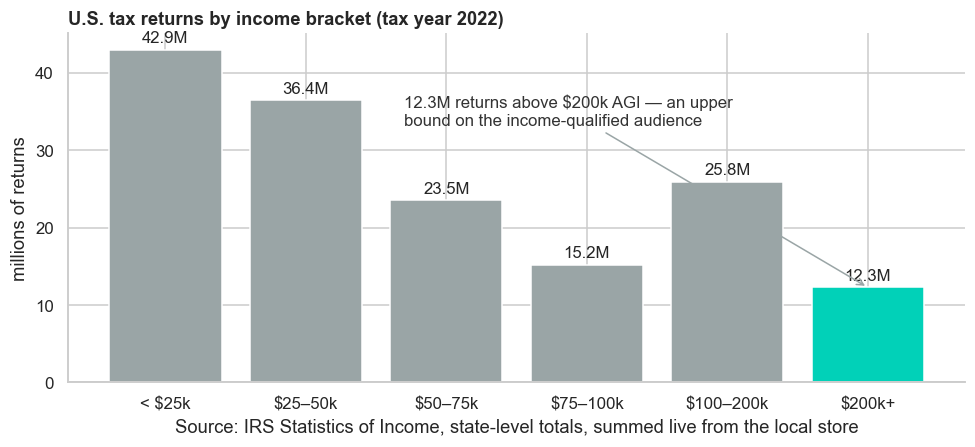

> **12.3 million U.S. tax returns — 7.9% of all filers — show AGI above $200k: a rough upper bound on the income-qualified audience (joint returns include couples who qualify only above $300k), before counting net-worth qualification.**

In [5]:
con = sqlite3.connect(SOI_DB)
brackets = pd.read_sql_query(
    "SELECT agi_stub, SUM(n1) AS returns FROM soi WHERE zipcode='00000' GROUP BY agi_stub", con)
con.close()
bracket_labels = ["< $25k", "$25–50k", "$50–75k", "$75–100k", "$100–200k", "$200k+"]
total_returns = brackets["returns"].sum()
over = int(brackets.loc[brackets.agi_stub == 6, "returns"].iloc[0])
share = over / total_returns * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [DIM] * 5 + [ACCENT]
bars = ax.bar(bracket_labels, brackets["returns"] / 1e6, color=colors)
ax.bar_label(bars, fmt="%.1fM", padding=3)
ax.set_title("U.S. tax returns by income bracket (tax year 2022)", loc="left", fontweight="bold")
ax.set_ylabel("millions of returns")
ax.set_xlabel("Source: IRS Statistics of Income, state-level totals, summed live from the local store")
ax.annotate(f"{over/1e6:.1f}M returns above \$200k AGI — an upper\nbound on the income-qualified audience",
            xy=(5, over / 1e6), xytext=(1.7, over / 1e6 + 21),
            arrowprops=dict(arrowstyle="->", color=DIM), color="#333")
plt.tight_layout(); plt.show()

callout(f"{over/1e6:.1f} million U.S. tax returns — {share:.1f}% of all filers — show AGI above "
        f"$200k: a rough upper bound on the income-qualified audience (joint returns include "
        f"couples who qualify only above $300k), before counting net-worth qualification.")

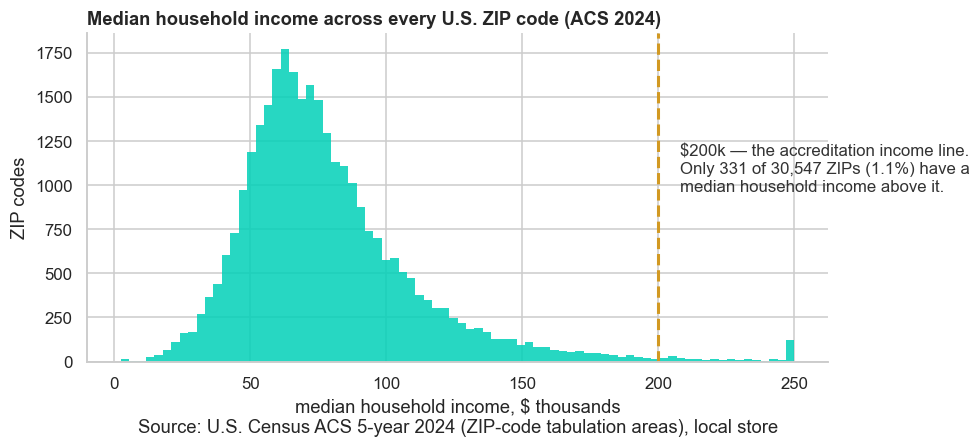

> **13.3% of U.S. households earn $200k+ — yet in only 331 of 30,547 ZIP codes (1.1%) is that the MEDIAN. Accreditation-level income is everywhere; it is concentrated almost nowhere.**

In [6]:
con = sqlite3.connect(ACS_DB)
zips = pd.read_sql_query(
    "SELECT median_household_income AS mhi, total_households AS hh, households_200k_plus AS hh200 "
    "FROM zcta WHERE median_household_income IS NOT NULL", con)
con.close()
n_zips = len(zips)
rich_zips = int((zips.mhi >= 200_000).sum())
hh_share = zips.hh200.sum() / zips.hh.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(zips.mhi / 1000, bins=80, color=ACCENT, alpha=0.85, ax=ax, edgecolor="none")
ax.axvline(200, color="#d29922", lw=2, ls="--")
ax.annotate(f"$200k — the accreditation income line.\nOnly {rich_zips} of {n_zips:,} ZIPs ({rich_zips/n_zips:.1%}) have a\nmedian household income above it.",
            xy=(200, ax.get_ylim()[1] * 0.5), xytext=(208, ax.get_ylim()[1] * 0.52), color="#333")
ax.set_title("Median household income across every U.S. ZIP code (ACS 2024)",
             loc="left", fontweight="bold")
ax.set_xlabel("median household income, $ thousands\nSource: U.S. Census ACS 5-year 2024 (ZIP-code tabulation areas), local store")
ax.set_ylabel("ZIP codes")
plt.tight_layout(); plt.show()

callout(f"{hh_share:.1f}% of U.S. households earn $200k+ — yet in only {rich_zips} of "
        f"{n_zips:,} ZIP codes ({rich_zips/n_zips:.1%}) is that the MEDIAN. Accreditation-level "
        f"income is everywhere; it is concentrated almost nowhere.")

Read those two charts together: the qualifying audience is in the **millions**, and it is
**geographically scattered** — high-earning households exist in nearly every ZIP code, but
in 99 of 100 they are a local minority. Private deal flow, meanwhile, has historically
concentrated inside a handful of metro networks and institutional relationships. A market
this large, served through channels that narrow, is the textbook definition of an access
gap. (One chart-reading note: the spike at the histogram's right edge is the ACS top-code —
ZIP medians are capped at \$250,001 — not a real cluster.)

## 4 · Access is becoming a product

For most of its history, the Regulation D market had no storefront. No exchange, no
ticker, no feed — an investor participated if and only if the right network knew their
name. And the IRS chart above holds a quiet implication: **accredited investor is a status,
not a membership** — millions of households earn qualifying income without ever having
been told the term applies to them, and most live far from the metros where private deal
flow has traditionally changed hands. No one in those networks knows their name; under the
old model, that was the end of the story.

That is what is changing. Regulated online platforms spent the last decade building the
rails — verification, disclosure, custody, online closing — and are now pointing them at
the accredited market itself: **Regulation D offerings delivered directly to accredited
investors and qualified purchasers** (StartEngine Private among them), with online
accreditation verification and minimums far below the institutional norm, alongside the
Regulation A and Regulation Crowdfunding offerings available to the public. If you earn
above the line in the chart, this market is now built to find you — wherever you live.

Put the three facts side by side: the public market offers a shrinking number of
companies, mostly after their fastest growth; the private market is where capital
formation actually happens — tens of thousands of placements and the better part of a
trillion dollars a year from operating companies alone; and the millions of investors
who qualify for it have, until
now, mostly been spectators. Many never knew they qualified; almost none were ever asked.
**The gap between where capital formation happens and who can conveniently participate in
it is the private-markets opportunity — and closing that gap is now a product, not a
privilege.** For investors who clear the accreditation bar, private markets are no longer
somewhere you need to be invited. They are somewhere you can simply go.

---

## Methods & reproducibility

With two noted exceptions, every figure in this notebook was pulled live from a primary
public source at run time — no analyst spreadsheets, no third-party estimates:

| Source | Data | Pulled via |
|---|---|---|
| Federal Reserve (FRED®) | Listed companies per million people | [`mcpwright-fred`](https://pypi.org/project/mcpwright-fred/) |
| SEC EDGAR | Form D / Form C filing counts & recent filings | [`mcpwright-edgar`](https://pypi.org/project/mcpwright-edgar/) |
| IRS Statistics of Income | Returns by AGI bracket (TY2022) | [`mcpwright-soi`](https://pypi.org/project/mcpwright-soi/) |
| U.S. Census (ACS 2024) | Median household income, every ZIP | [`mcpwright-census`](https://pypi.org/project/mcpwright-census/) |

The four data connectors are open-source [MCP](https://modelcontextprotocol.io) servers
([mcpwright.com](https://mcpwright.com)) — the same tools work inside an AI assistant, which
is how this analysis was first prototyped. The full notebook, with all code, lives at
[github.com/StartEngine/private-markets-research](https://github.com/StartEngine/private-markets-research/blob/main/private_markets.ipynb). To reproduce: `uv sync`, set a free
`FRED_API_KEY`, run `mcpwright-soi setup` and `mcpwright-census setup` once, then run all
cells. Dollar aggregates for exempt offerings are from the SEC's published
[capital formation statistics](https://www.sec.gov/data-research/statistics-data-visualizations/regulation-d-offerings).

Counting notes: Form D counts are initial filings only (form type `D`; amendments file
as `D/A` and are excluded), assembled month-by-month because EDGAR's search index caps any
single count at 10,000. The two SEC-reported dollar aggregates (≈\$949B exempt /
≈\$28B IPO, July 2023–June 2024) are transcribed from the SEC Office of the Advocate for
Small Business Capital Formation's annual report — the only figures not produced by the
code. Source vintages differ: IRS SOI is tax year 2022, Census ACS is the 2024 5-year
release, the World Bank listings series ends in 2019, and EDGAR counts are as of the run
date.

*This document is for informational and educational purposes only and is not investment
advice, an offer, or a solicitation. Past or aggregate market activity does not predict
the performance of any investment. Investments in private companies involve a high degree
of risk, including total loss of capital.*

*This product uses the FRED® API but is not endorsed or certified by the Federal Reserve
Bank of St. Louis. FRED® and ALFRED® are trademarks of the Federal Reserve Bank of
St. Louis. SEC EDGAR, IRS SOI, and U.S. Census data are public records.*

In [7]:
await fred_client.aclose()
await edgar_client.aclose()